In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

1.9997233986062306


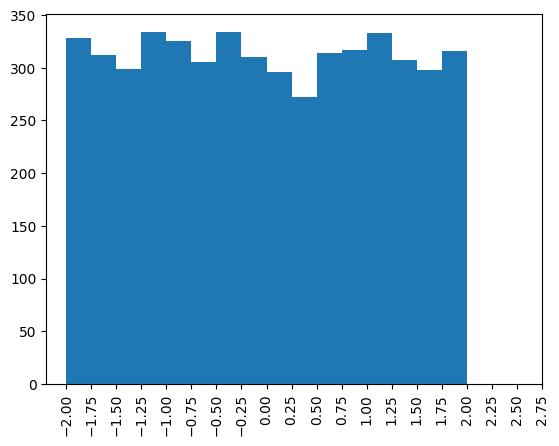

In [13]:
# Generate random numbers from a Uniform(-10, 10)
uniforms = np.random.uniform(low=-2, high=2, size=5000)

print(uniforms.max())

# Plot a histogram of uniform values, binwidth 0.25
plt.hist(uniforms, bins=np.arange(-2,2.000011,0.25))
plt.xticks(np.arange(-2, 3, 0.25))
plt.xticks(rotation=90)
plt.show()


In [ ]:
def parent_func():
    print("This is the parent function.")   
    def child_func(x=100):
        print("This is the child function.")
        #print(f"x = {x}")
        return
    return child_func

output = parent_func()
print(output())



This is the parent function.
This is the child function.
Thomas


In [4]:
import numpy as np
import pandas as pd




my_df = pd.DataFrame({
    'A': np.random.uniform(low=-10, high=10, size=1000)
})


my_df = my_df.reset_index()
    

my_df_samples = my_df.sample(frac=1, random_state=42,replace=True)

num_unique_values1 = my_df_samples['index'].nunique()
num_unique_values2 = len(my_df_samples.drop_duplicates(subset='index'))
num_unique_values3 = len(my_df_samples['index'].unique())

print(num_unique_values1)
print(num_unique_values2)
print(num_unique_values3)












615
615
615


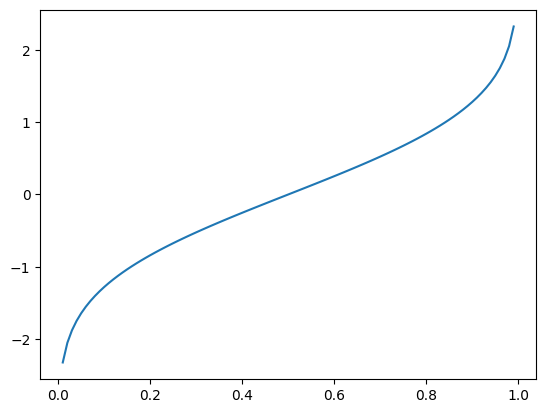

In [5]:
import numpy as np
from scipy.stats import norm
from matplotlib import pyplot as plt

quantile = np.arange(0.00, 1.01, 0.01)
y_vals = norm.ppf(quantile, loc=0, scale=1)

plt.plot(quantile, y_vals)







     x_vals   z_distn   t_distn
0     -5.00  0.000001  0.012243
1     -4.98  0.000002  0.012337
2     -4.96  0.000002  0.012433
3     -4.94  0.000002  0.012530
4     -4.92  0.000002  0.012628
..      ...       ...       ...
496    4.92  0.000002  0.012628
497    4.94  0.000002  0.012530
498    4.96  0.000002  0.012433
499    4.98  0.000002  0.012337
500    5.00  0.000001  0.012243

[501 rows x 3 columns]


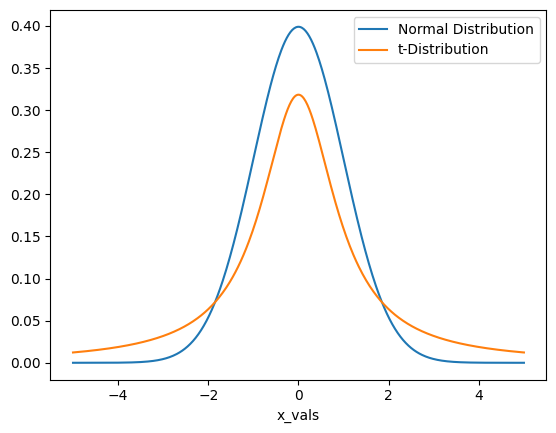

In [14]:

import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.stats import t
from matplotlib import pyplot as plt


x_vals = np.arange(-5, 5.02, 0.02) 
y_vals = norm.pdf(x_vals, loc=0, scale=1)
#plt.plot(x_vals, y_vals, label='Normal Distribution')

t_vals = t.pdf(x_vals, loc=0, scale=1,df=1)

df_distn = pd.DataFrame({
    'x_vals': x_vals,
    'z_distn': y_vals,
    't_distn': t_vals
})


df_distn.plot(x='x_vals', kind='line',y=['z_distn', 't_distn'], label=['Normal Distribution', 't-Distribution'])


#plt.show()

print (df_distn)


C:\Users\tombe\AppData\Local\Temp\ipykernel_30588\2909936136.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_a['x'], df_b['x'], df_c['x']], labels=['a', 'b', 'c'])


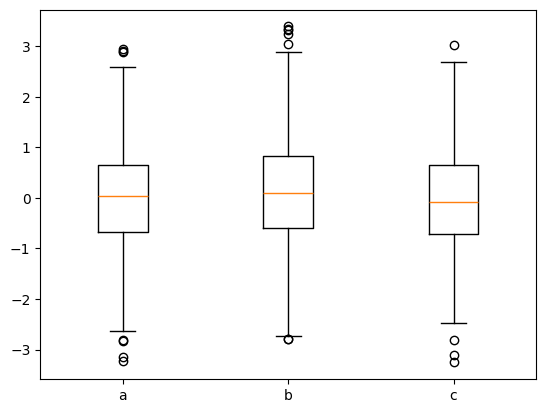

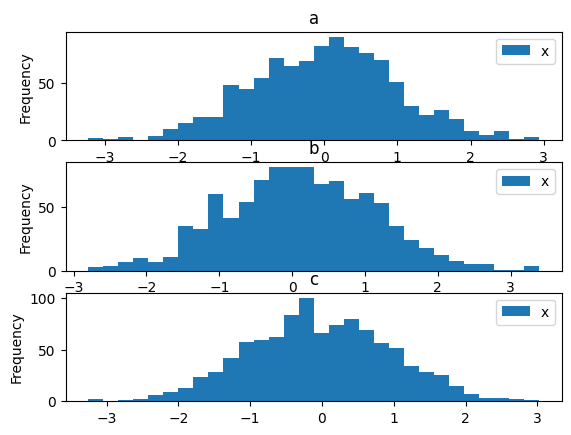

  Source  ddof1  ddof2         F     p_unc       np2
0  level      2   2997  5.586448  0.003787  0.003714


  Contrast  A  B  Paired  Parametric         T     dof alternative     p_unc  \
0    level  a  b   False        True -2.403989  1998.0   two-sided  0.016308   
1    level  a  c   False        True  0.792855  1998.0   two-sided  0.427956   
2    level  b  c   False        True  3.181215  1998.0   two-sided  0.001489   

    BF10    hedges  
0  0.882 -0.107469  
1  0.069  0.035444  
2  7.542  0.142215  


In [126]:

import pingouin as pg
import pandas as pd
import numpy as np

x1 = np.random.normal(loc=0, scale=1, size=1000)
x2 = np.random.normal(loc=0.1, scale=1, size=1000)
x3 = np.random.normal(loc=0.0, scale=1, size=1000)

df_a = pd.DataFrame({'x': x1,'level': 'a'})
df_b = pd.DataFrame({'x': x2, 'level': 'b'})
df_c = pd.DataFrame({'x': x3, 'level': 'c'})
df_test = pd.concat([df_a, df_b,df_c], ignore_index=True)

plt.boxplot([df_a['x'], df_b['x'], df_c['x']], labels=['a', 'b', 'c'])

df_test.plot(kind='hist', bins=30,by='level')
plt.show()
print(pg.anova(data=df_test, dv='x', between='level'))
print("\n")
print(pg.pairwise_tests(data=df_test, dv='x', between='level',padjust='none'))



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest

x1 = np.random.binomial(n=1, p=0.7, size=1000)
x2 = np.random.binomial(n=1, p=0.65, size=1500)

df_a = pd.DataFrame({'x': x1,'group': 'a'})
df_b = pd.DataFrame({'x': x2, 'group': 'b'})


df_test = pd.concat([df_a, df_b], ignore_index=True)
df_test = df_test.replace({'x': {0: 'no', 1: 'yes'}})

print(df_test.value_counts())

n_yes = df_test[df_test['x'] == 'yes'].groupby('group').size().to_list()     
n_total = df_test.groupby('group').size().to_list()

print(n_yes)
print(n_total)

z_score, p_value = proportions_ztest(count=n_yes, nobs=n_total,alternative='two-sided')
print(f"Z-score: {z_score}, P-value: {p_value}")


import pingouin
expected, observed, stats = pingouin.chi2_independence ( data = df_test , x = 'group' ,  y='x' , correction = False)

print(expected)
print(observed)
print(stats)






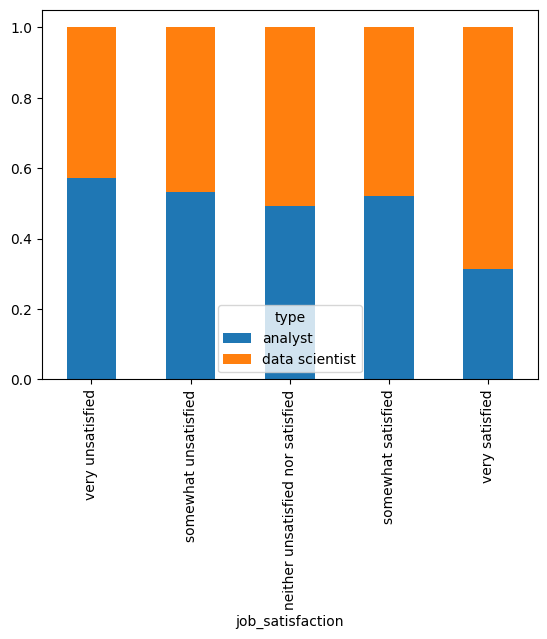


chi-squared expected counts are:

type                               analyst  data scientist
job_satisfaction                                          
very unsatisfied                       7.0             7.0
somewhat unsatisfied                  22.5            22.5
neither unsatisfied nor satisfied     38.5            38.5
somewhat satisfied                    24.0            24.0
very satisfied                         8.0             8.0

chi-squared observed counts are:

type                               analyst  data scientist
job_satisfaction                                          
very unsatisfied                         8               6
somewhat unsatisfied                    24              21
neither unsatisfied nor satisfied       38              39
somewhat satisfied                      25              23
very satisfied                           5              11

chi-squared stats are:

                 test    lambda      chi2  dof      pval    cramer     power
0 

In [27]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pingouin

# Generate random data for two groups
x1 = np.random.normal(loc=0.0, scale=1, size=100)
x2 = np.random.normal(loc=0.2, scale=1, size=100)

# Create a DataFrame with the data
df_a = pd.DataFrame({'x': x1,'type': 'analyst'})
df_b = pd.DataFrame({'x': x2, 'type': 'data scientist'})

# Combine the DataFrames
df_test = pd.concat([df_a, df_b], ignore_index=True)

# Create categorical variable for job satisfaction based on 'x' values
labels=['very unsatisfied', 'somewhat unsatisfied', 'neither unsatisfied nor satisfied', 'somewhat satisfied', 'very satisfied']
bins=[-np.inf, -1.5, -0.5, 0.5, 1.5, np.inf]
df_test['job_satisfaction'] = pd.cut(df_test['x'], labels=labels, bins=bins)
del df_test['x']

# Construct data for plotting
df_plot = df_test.groupby('job_satisfaction')['type'].value_counts(normalize=True).unstack(level=-1)

# Plot the data
df_plot.plot(kind='bar', stacked=True)
plt.show()

# perform the chi-squared test of independence
expected, observed, stats = pingouin.chi2_independence ( data = df_test , x = 'job_satisfaction' ,  y='type' , correction = False)

# Print the results of the chi-squared test
print(f"\nchi-squared expected counts are:\n\n{expected}")
print(f"\nchi-squared observed counts are:\n\n{observed}")
print(f"\nchi-squared stats are:\n\n{stats}")



In [20]:
print(df_test.groupby(['job_satisfaction','type']).size())

print(df_test.groupby(['job_satisfaction','type']).size().unstack() )


job_satisfaction                   type          
very unsatisfied                   analyst            9
                                   data scientist     4
somewhat unsatisfied               analyst           22
                                   data scientist    23
neither unsatisfied nor satisfied  analyst           28
                                   data scientist    37
somewhat satisfied                 analyst           28
                                   data scientist    27
very satisfied                     analyst           13
                                   data scientist     9
dtype: int64
type                               analyst  data scientist
job_satisfaction                                          
very unsatisfied                         9               4
somewhat unsatisfied                    22              23
neither unsatisfied nor satisfied       28              37
somewhat satisfied                      28              27
very satisfied         

In [31]:

my_list = [round(np.random.uniform(0, 30)) for _ in range(10)]

print(my_list)

from scipy.stats import rankdata
ranks_of_my_list = rankdata(my_list)
print(ranks_of_my_list)



[25, 0, 10, 6, 3, 10, 22, 28, 21, 27]
[ 8.   1.   4.5  3.   2.   4.5  7.  10.   6.   9. ]


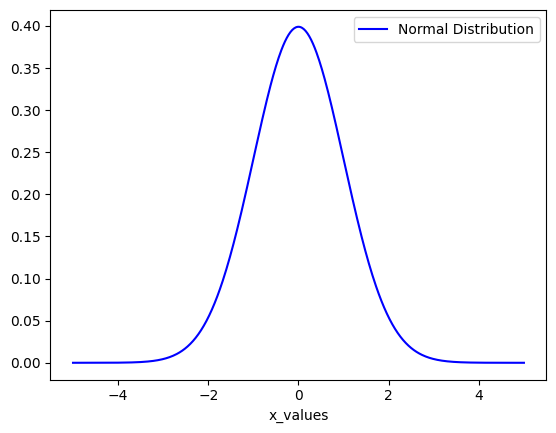

In [2]:

import pingouin as pg
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt 

x = np.arange(-5, 5.02, 0.02)
pdf_norm = stats.norm.pdf(x, loc=0, scale=1)
 
df_a = pd.DataFrame({'pdf_norm_values': pdf_norm, 'x_values':x ,  'level': 'a'})

#df_test = pd.concat([df_a, df_b,df_c], ignore_index=True)

#plt.boxplot([df_a['x'], df_b['x'], df_c['x']], labels=['a', 'b', 'c'])

df_a.plot(kind='line', x='x_values', y='pdf_norm_values', color='blue', label='Normal Distribution')
plt.show()






  Condition_A Condition_B  values
0        High          On      19
1         Low         Off      20
2         Low          On      21
3        High         Off      20


<Axes: xlabel='Condition_B', ylabel='Condition_A'>

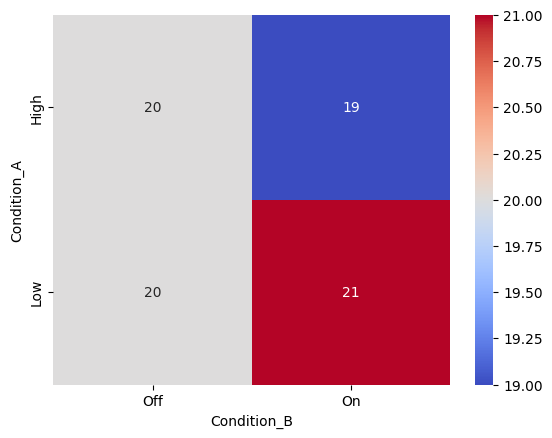

In [12]:
import pandas as pd
import seaborn as sns


df_test = pd.DataFrame({'Condition_A':['High','Low','Low','High'],'Condition_B':['On','Off','On','Off'],'values':[19,20,21,20]})

print(df_test)  

df_pivot = pd.pivot(df_test, index='Condition_A', columns='Condition_B', values='values')

sns.heatmap(df_pivot, annot=True, cmap='coolwarm',fmt='g'  )





  sex  adj_weight  sys_bp
0   F        59.0     109
1   F        54.0     109
2   F        61.0     120
3   F        56.0      99
4   F        48.0      88


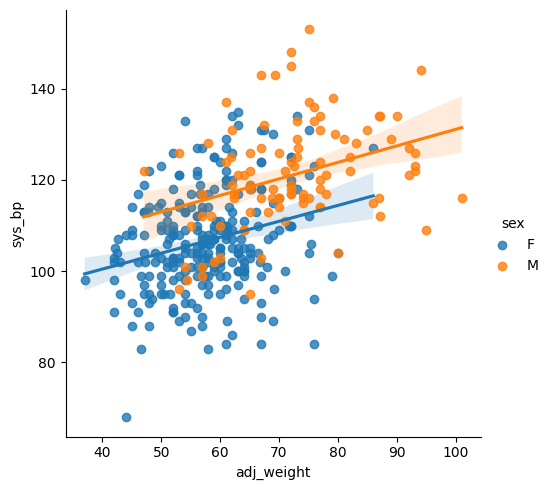

                            OLS Regression Results                            
Dep. Variable:                 sys_bp   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     80.36
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           1.32e-29
Time:                        16:35:47   Log-Likelihood:                -1382.9
No. Observations:                 365   AIC:                             2772.
Df Residuals:                     362   BIC:                             2784.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     86.1899      3.624     23.782      0.0

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols


file_path = r'C:\Users\tombe\Downloads\experimental data ms1.xlsx'

df_data = pd.read_excel(file_path, sheet_name=0)
df_data.columns = df_data.columns.str.lower()
df_data.columns = df_data.columns.str.replace('.', '_')

print(df_data.head())
sns.lmplot(data=df_data, x='adj_weight', y='sys_bp', hue='sex')
plt.show()


model = ols ('sys_bp ~ sex + adj_weight' , data = df_data ).fit()
print(model.summary())

model = ols ('sys_bp ~ sex' , data = df_data ).fit()
print(model.summary())




In [ ]:


my_list=['Tom Hard','Phillip Good','Becky Jones']
for x, y in enumerate(my_list):
    print (str(x) + ': ' +       y)

0: Tom Hard
1: Phillip Good
2: Becky Jones


<Axes: xlabel='sample_size', ylabel='power'>

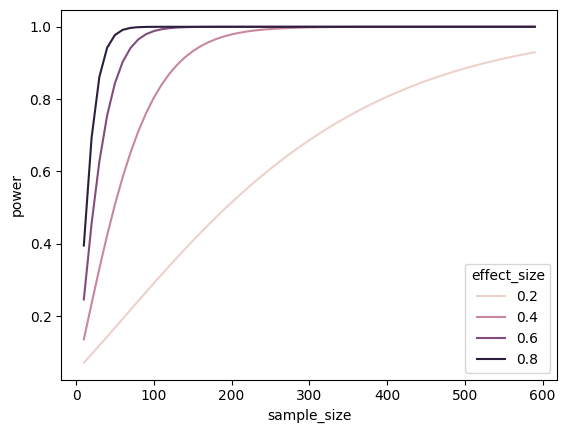

In [ ]:

from statsmodels.stats.power import TTestIndPower
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

power_analysis = TTestIndPower()
dict_power = {}

rows = []

for detect_effect in [0.2,0.4, 0.6, 0.8]:

    for sample_size in np.arange(10, 600, 10):

        power = power_analysis.solve_power(effect_size=detect_effect, nobs1=sample_size, alpha=0.05)
        
        rows.append({
        'effect_size': detect_effect,
        'sample_size': sample_size,
        'power': power
        })
            
        
df_power = pd.DataFrame(rows)
sns.lineplot(data=df_power, x='sample_size', y='power', hue='effect_size')



In [87]:
import pandas as pd
import seaborn as sns



file_path = r"C:\Users\tombe\Python\Data\ROCK_sc_10.xlsx"

df_rocks = pd.read_excel(file_path)

df_rocks.describe()
df_rocks.info()

<class 'pandas.DataFrame'>
RangeIndex: 4025 entries, 0 to 4024
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Source             4025 non-null   int64  
 1   Country            3857 non-null   str    
 2   Rock Class         4000 non-null   str    
 3   Rock Type          3897 non-null   str    
 4   ρd                 1918 non-null   float64
 5   γ                  1918 non-null   float64
 6   n                  1371 non-null   float64
 7   Vp                 2366 non-null   float64
 8   RL                 2162 non-null   float64
 9   Is (50)            2348 non-null   float64
 10  σbt                582 non-null    float64
 11  BPI                380 non-null    float64
 12  mi (guidelines)    3994 non-null   float64
 13  σc                 3997 non-null   float64
 14  E                  953 non-null    float64
 15  Ri                 566 non-null    float64
 16  mi (guidelines).1  3986 non-null   